# Karun Mokha — Controlled ImageNet-32 Data-Scaling Experiment

**Course:** UW CSED 504  
**Project:** Model Factory  
**Contribution:** Deterministic stratified ImageNet-32 subsets  
**Pull Request:** #22  
**Author:** Karun Mokha

## Overview

This contribution creates a controlled data-scaling framework for comparing
ResNet-18 and Vision Transformer models on ImageNet-32.

The team had previously observed that ResNet-18 performed substantially better
than ViT on CIFAR-10, while ViT slightly outperformed ResNet-18 on ImageNet-32.
However, moving from CIFAR-10 to ImageNet-32 changes dataset size, dataset
identity, number of classes, task difficulty, and training configuration at the
same time.

My contribution enables a more controlled experiment by training both
architectures on the exact same stratified 5%, 10%, 25%, 50%, and 100%
subsets of ImageNet-32.

## Research Question

How does the relative performance of a parameter-matched ResNet-18 and Vision
Transformer change as the amount of ImageNet-32 training data increases, while
holding the following constant?

- Dataset identity
- 1,000-class prediction task
- Image resolution
- Validation set
- Class distribution
- Selected training examples for each seed

The eventual output will be an accuracy-versus-data-scale curve for both model
families and a plot of:

\[
\text{ViT validation accuracy} - \text{ResNet validation accuracy}
\]

as a function of training-set size.

## Implementation

The contribution added five main components:

| File | Purpose |
|---|---|
| `subsets.py` | Creates deterministic proportional stratified subsets |
| `subset_report.py` | Validates and reports subset properties |
| `test_subsets.py` | Tests determinism, allocation, coverage, and manifest reuse |
| `imagenet_data.py` | Loads selected subset rows into the training pipeline |
| `train_run.py` | Adds configurable `--train-fraction` support |

### Subset-generation procedure

1. Read all ImageNet-32 training labels.
2. Calculate the requested subset size.
3. Allocate examples proportionally across all 1,000 classes.
4. Sample without replacement using a fixed random seed.
5. Save the exact selected row indices in a manifest.
6. Record SHA-256 checksums for the source labels and selected indices.
7. Reuse the same manifest for ResNet and ViT runs.

This ensures that architecture comparisons at a given fraction and seed use
the exact same training images.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.8f}")

In [7]:
subset_results = pd.DataFrame(
    {
        "fraction": [0.05, 0.10, 0.25, 0.50, 1.00],
        "images": [64058, 128117, 320292, 640584, 1281167],
        "classes_present": [1000, 1000, 1000, 1000, 1000],
        "minimum_per_class": [37, 73, 183, 366, 732],
        "maximum_per_class": [65, 130, 325, 650, 1300],
        "mean_per_class": [64.06, 128.12, 320.29, 640.58, 1281.17],
        "total_variation_distance": [
            0.000231,
            0.000110,
            0.000043,
            0.000021,
            0.000000,
        ],
        "maximum_class_share_error": [
            0.00001014,
            0.00000469,
            0.00000156,
            0.00000078,
            0.00000000,
        ],
        "seed_overlap": [0.0506, 0.1001, 0.2492, 0.5007, 1.0000],
    }
)

subset_results["fraction_percent"] = (
    subset_results["fraction"] * 100
)

subset_results

,fraction,images,classes_present,minimum_per_class,maximum_per_class,mean_per_class,total_variation_distance,maximum_class_share_error,seed_overlap,fraction_percent
0,0.05000000,64058,1000,37,65,64.06000000,0.00023100,0.00001014,0.05060000,5.00000000
1,0.10000000,128117,1000,73,130,128.12000000,0.00011000,0.00000469,0.10010000,10.00000000
2,0.25000000,320292,1000,183,325,320.29000000,0.00004300,0.00000156,0.24920000,25.00000000
3,0.50000000,640584,1000,366,650,640.58000000,0.00002100,0.00000078,0.50070000,50.00000000
4,1.00000000,1281167,1000,732,1300,1281.17000000,0.00000000,0.00000000,1.00000000,100.00000000


## Results

The real ImageNet-32 training label array contained:

- **1,281,167 training examples**
- **1,000 classes**
- Labels ranging from **0 through 999**

Every requested subset retained all 1,000 classes.

The 5% subset contained 64,058 examples, with between 37 and 65 examples per
class. The 50% subset contained 640,584 examples, with between 366 and 650
examples per class.

The maximum observed total variation distance was only 0.000231 at the 5%
scale. This indicates that even the smallest subset remained extremely close
to the original ImageNet-32 class distribution.

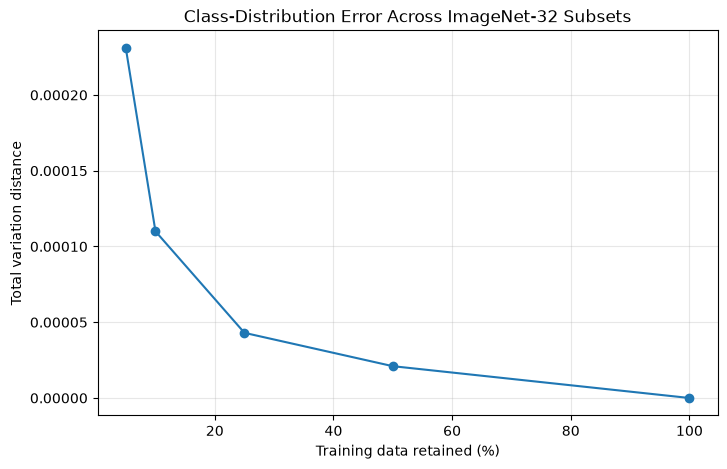

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    subset_results["fraction_percent"],
    subset_results["total_variation_distance"],
    marker="o",
)

ax.set_title("Class-Distribution Error Across ImageNet-32 Subsets")
ax.set_xlabel("Training data retained (%)")
ax.set_ylabel("Total variation distance")
ax.grid(True, alpha=0.3)

plt.show()

The distribution error decreases as the subset grows and reaches zero for the
complete dataset. Even at 5%, the error is very small, demonstrating that the
scaling experiment changes data quantity without materially changing class
composition.

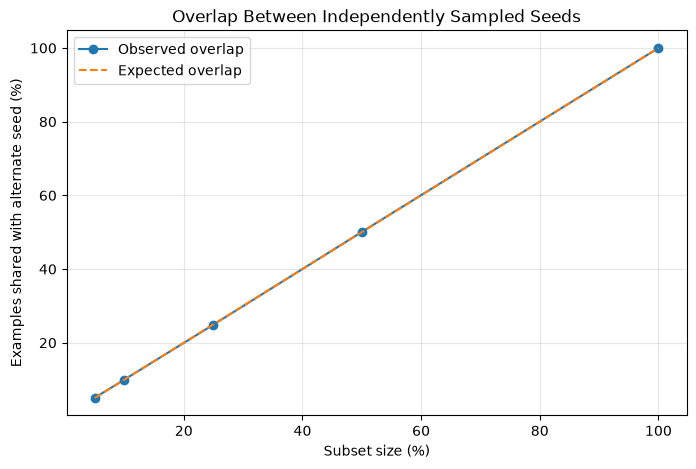

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    subset_results["fraction_percent"],
    subset_results["seed_overlap"] * 100,
    marker="o",
    label="Observed overlap",
)

ax.plot(
    subset_results["fraction_percent"],
    subset_results["fraction_percent"],
    linestyle="--",
    label="Expected overlap",
)

ax.set_title("Overlap Between Independently Sampled Seeds")
ax.set_xlabel("Subset size (%)")
ax.set_ylabel("Examples shared with alternate seed (%)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

Two independently sampled subsets containing fraction \(p\) of a dataset are
expected to share approximately fraction \(p\) of their selected examples.

The observed overlap closely matches this expectation:

- 5% subsets overlap by 5.06%
- 10% subsets overlap by 10.01%
- 25% subsets overlap by 24.92%
- 50% subsets overlap by 50.07%
- 100% subsets overlap completely

This shows that different seeds produce meaningfully different samples while
preserving the same controlled class distribution.

## Validation and Reproducibility

The subset implementation was validated using CPU-only unit tests covering:

- Exact target subset size
- Deterministic output for the same seed
- Different selected rows for different seeds
- Identical per-class allocations across seeds
- Representation of every class when the subset is sufficiently large
- Saved-manifest reuse
- Input validation and failure handling

All current subset tests passed without errors.

The real-label validation command was:

```powershell
python src/a1-cv/subset_report.py `
    --fractions 0.05 0.10 0.25 0.50 1.0 `
    --seed 42 `
    --compare-seed 43

## What These Results Establish

The completed results validate the experimental control rather than final model accuracy.

They establish that:

1. Every planned data scale retains all 1,000 ImageNet classes.
2. Class proportions remain nearly identical to the complete dataset.
3. A fixed seed reproduces the exact same training examples.
4. Different seeds produce appropriately different samples.
5. ResNet and ViT can be assigned the same manifest and therefore the exact same training data.

This removes a major confound from the original CIFAR-10 versus ImageNet-32 comparison.

## Limitations

The final paired ResNet-18 and ViT training matrix has not yet been completed.

The local development computer did not have an NVIDIA CUDA device, while the
current ImageNet-32 training pipeline uses CUDA mixed precision, GPU-resident
image arrays, and GPU-side augmentation.

Therefore, the results in this notebook should not be interpreted as evidence
that either architecture currently performs better. They validate that the
planned comparison is controlled and reproducible.

Additional limitations include:

- Final model runs should use multiple seeds.
- Equal epochs do not necessarily represent equal compute.
- Architecture-optimized recipes change more than architecture alone.
- The full study should distinguish family-optimized comparisons from strictly
  controlled training-recipe comparisons.

## Next Steps

1. Run paired two-epoch pilots for ResNet-18 and ViT on the 5% subset.
2. Confirm that both model results reference the same manifest checksum.
3. Run the full 5%, 10%, 25%, 50%, and 100% experiment matrix.
4. Repeat the most important configurations across multiple seeds.
5. Record:
   - Validation top-1 accuracy
   - Validation top-5 accuracy
   - Validation loss
   - Training time
   - Throughput
   - Peak GPU memory
   - Best epoch
6. Plot validation accuracy against the logarithm of training-set size.
7. Plot the ViT-minus-ResNet accuracy difference at every data scale.
8. Determine whether the currently observed cross-dataset reversal also appears
   in a controlled within-dataset scaling experiment.

## Conclusion

I implemented and validated a deterministic ImageNet-32 data-scaling system for
the Model Factory project.

The contribution transforms the original two-dataset comparison into a
controlled experimental design. Rather than comparing CIFAR-10 directly with
ImageNet-32, the group can now compare ResNet-18 and ViT across multiple sizes
of the same 1,000-class ImageNet-32 task.

The validation results show that all planned subsets retain every class,
preserve the source class distribution with extremely low error, and support
reproducible example selection through saved manifests and checksums.

This provides the experimental infrastructure needed to test whether the
relative CNN–ViT performance genuinely changes as training-data scale
increases.